ESERCIZIO

Genera uno scatter plot 2D per il dataset MINST usante un VAE pre-addestrato.
Identifica i centroidi per le classi 3 e 8
Esegui un'interpolazione lineare tra questi due punti salvando 10 immagni intermedie.
Commenta come cambia la fomra della cifra durenta il passaggio.
Suggerimento: usa 'plt.scatter' con il parametro 'c' impostata sulle laberl per ottenere la colorazione per classe.

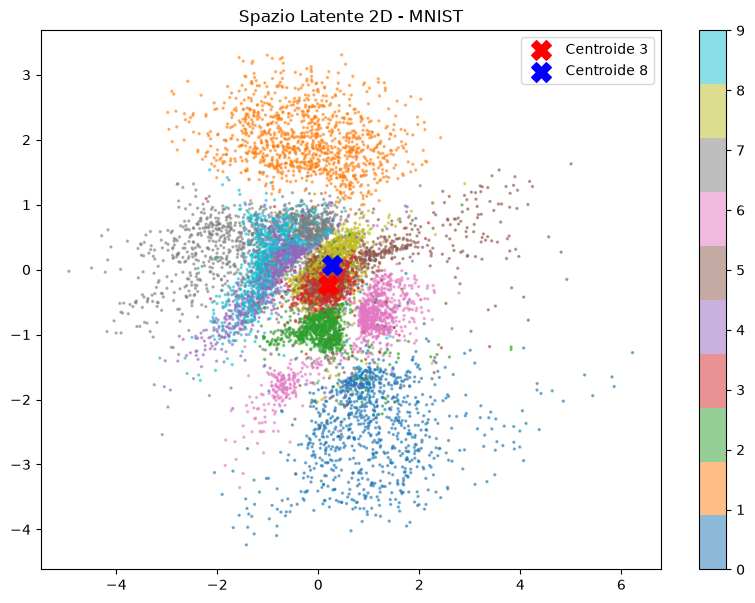

C:\Users\barbara\AppData\Local\Temp\ipykernel_52968\1778754991.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  interp_latents = torch.tensor([(1-a)*centroid_3 + a*centroid_8 for a in alphas]).float().to(device)


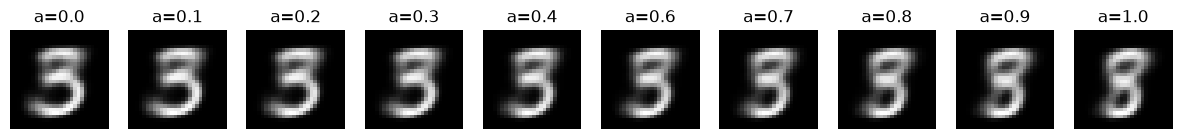

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURAZIONE E CARICAMENTO DATI ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 2  # Obbligatorio a 2 per lo scatter plot diretto
batch_size = 128
epochs = 10

transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(datasets.MNIST('.', train=False, transform=transform), batch_size=1000, shuffle=False)

# --- 2. DEFINIZIONE MODELLO (VAE) ---
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 400), nn.ReLU(),
            nn.Linear(400, 200), nn.ReLU()
        )
        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logvar = nn.Linear(200, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200), nn.ReLU(),
            nn.Linear(200, 400), nn.ReLU(),
            nn.Linear(400, 784), nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# --- 3. ADDESTRAMENTO RAPIDO ---
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(epochs):
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        # Loss semplificata (Beta=1)
        BCE = nn.functional.binary_cross_entropy(recon, data.view(-1, 784), reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        (BCE + KLD).backward()
        optimizer.step()

# --- 4. VISUALIZZAZIONE SPAZIO LATENTE E CENTROIDI ---
model.eval()
z_list, label_list = [], []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.fc_mu(model.encoder(data.view(-1, 784))), None
        z_list.append(mu.cpu().numpy())
        label_list.append(labels.numpy())

z_all = np.concatenate(z_list)
labels_all = np.concatenate(label_list)

# Calcolo Centroidi per '3' e '8'
centroid_3 = z_all[labels_all == 3].mean(axis=0)
centroid_8 = z_all[labels_all == 8].mean(axis=0)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(z_all[:, 0], z_all[:, 1], c=labels_all, cmap='tab10', alpha=0.5, s=2)
plt.colorbar(scatter)
plt.scatter(centroid_3[0], centroid_3[1], c='red', marker='X', s=200, label='Centroide 3')
plt.scatter(centroid_8[0], centroid_8[1], c='blue', marker='X', s=200, label='Centroide 8')
plt.title("Spazio Latente 2D - MNIST")
plt.legend()
plt.show()

# --- 5. INTERPOLAZIONE LINEARE ---
# Formula: z(alpha) = (1 - alpha) * z_start + alpha * z_end
alphas = np.linspace(0, 1, 10)
interp_latents = torch.tensor([(1-a)*centroid_3 + a*centroid_8 for a in alphas]).float().to(device)

with torch.no_grad():
    interp_imgs = model.decoder(interp_latents).cpu().view(-1, 28, 28)

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(interp_imgs[i], cmap='gray')
    plt.axis('off')
    plt.title(f"a={alphas[i]:.1f}")
plt.show()